# Analysing results


## Loading just 1 file

In [1]:
# import libraries
import numpy as np, scipy as sp, matplotlib.pyplot as plt, os
import quadratureNetwork as qnet #library that implement the oscillators

def analyze_files(file_names, n=3, numOscillators=10, annot=False):
  """
  Analyzes the given list of files and plots the results.

  Parameters:
  file_names (list): List of file names to analyze.
  """
  for fileName in file_names:
    npzfile = sp.io.loadmat(fileName)
    params = npzfile['params']
    x = npzfile['x']
    Rf = npzfile['Rf'][0][0]
    pc = npzfile['pc'][0]
    pcMean = npzfile['pcMean']
    pcStd = npzfile['pcStd']

    t = np.arange(0, len(x), 1) * 0.005

    # Create subplots with different width ratios
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), gridspec_kw={'width_ratios': [3, 1.5]})

    # Plot sine wave on the first subplot
    ax1.plot(t, x[:, ::3])
    ax1.set_xlim(115, 120)
    ax1.set_xlabel('time (s)')
    ax1.set_title(r'$R_f = %.0f~\mathrm{k}\Omega$   |    $r = %.4f$' % (Rf/1000, pc.mean()))

    # Plot clustered order parameter matrix on the second subplot
    plt.sca(ax2)
    qnet.plot_clustered_order_parameter_matrix(x, n=n, numOscillators=numOscillators, annot=annot)
    ax2.set_xlabel('oscillator #')
    ax2.set_ylabel('oscillator #')
    ax2.set_title('Pairwise Order Param.' % pc.mean())
    ax2.set_aspect('equal')
    # Adjust layout
    plt.tight_layout()
    plt.show()
  return x, t, params, Rf, pc, pcMean, pcStd

g:\My Drive\UFMG\Pesquisa\202103 - Fapemig\RedesDinamicas\04 - Publicacoes\202503 - SBAI\code\quadratureNetwork.py:374: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit


## Exp001

In [1]:
exp001 = ['exp001\\Rf_00010000.mat', 'exp001\\Rf_00020000.mat', 'exp001\\Rf_00070000.mat']
analyze_files(exp001, n=3, numOscillators=2, annot=False);

NameError: name 'analyze_files' is not defined

## Exp002

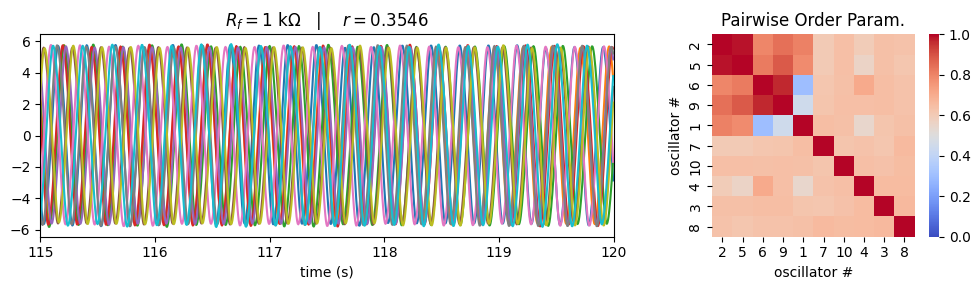

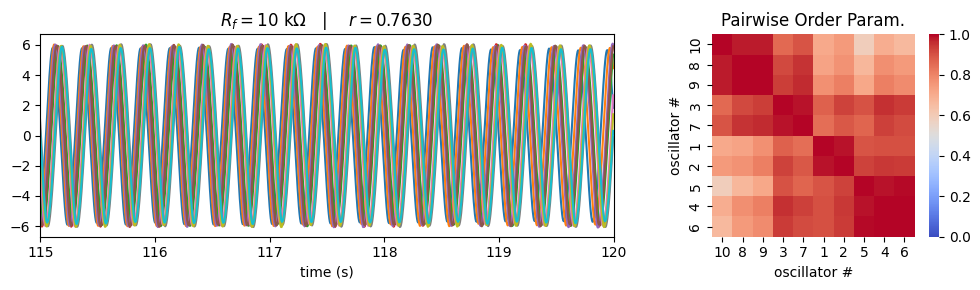

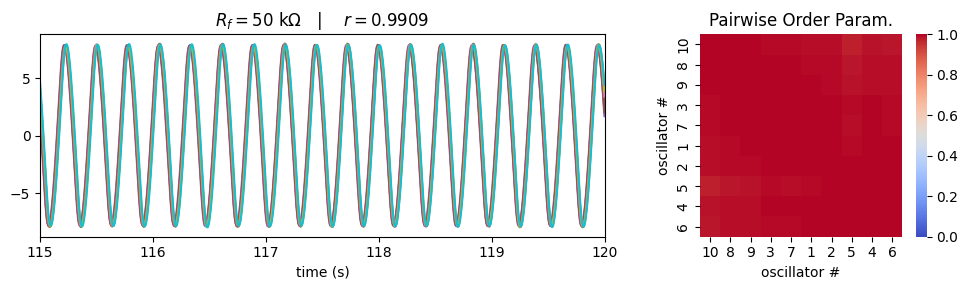

In [3]:
exp002 = ['exp002\\Rf_00001000.mat', 'exp002\\Rf_00010000.mat', 'exp002\\Rf_00050000.mat']
x, t, params, Rf, pc, pcMean, pcStd = analyze_files(exp002, n=3, numOscillators=10, annot=False);

## Exp003

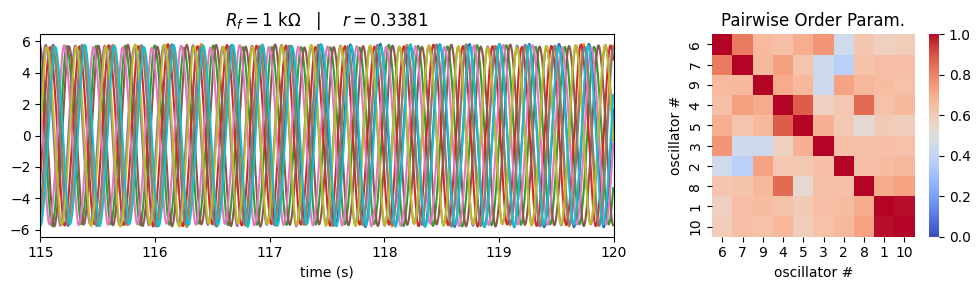

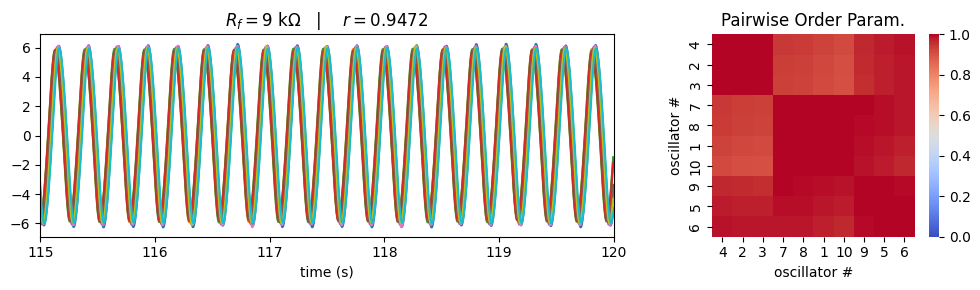

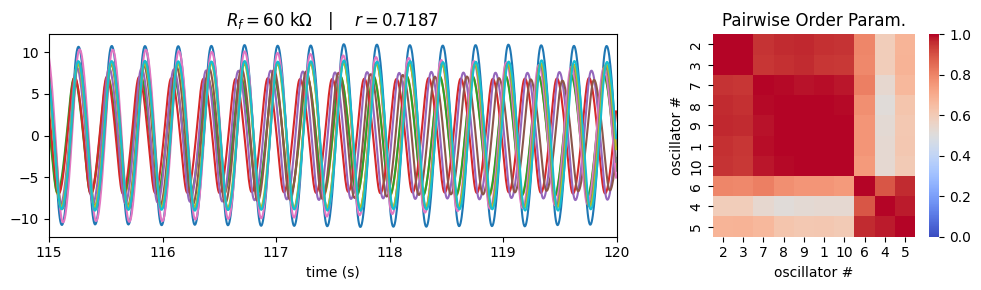

In [11]:
exp003 = ['exp003\\Rf_00001000.mat', 'exp003\\Rf_00009000.mat', 'exp003\\Rf_00060000.mat'] #, 'exp003\\Rf_00031000.mat'] # <-- interessante esse
analyze_files(exp003, n=3, numOscillators=10, annot=False);

## Exp004

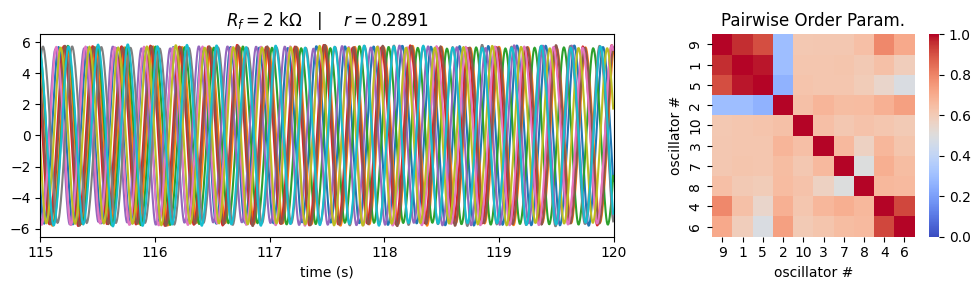

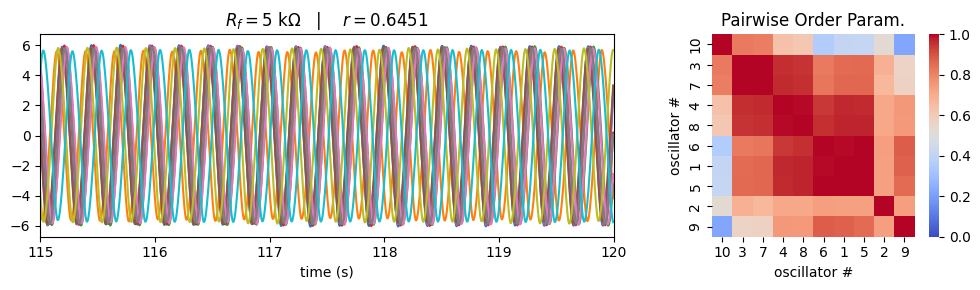

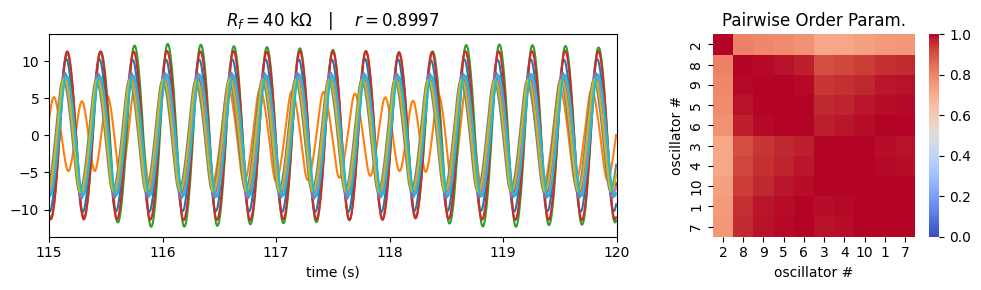

In [3]:
exp004 = ['exp004\\Rf_00002000.mat', 'exp004\\Rf_00005000.mat', 'exp004\\Rf_00040000.mat']
analyze_files(exp004, n=3, numOscillators=10, annot=False);

# Analysing a single experiment

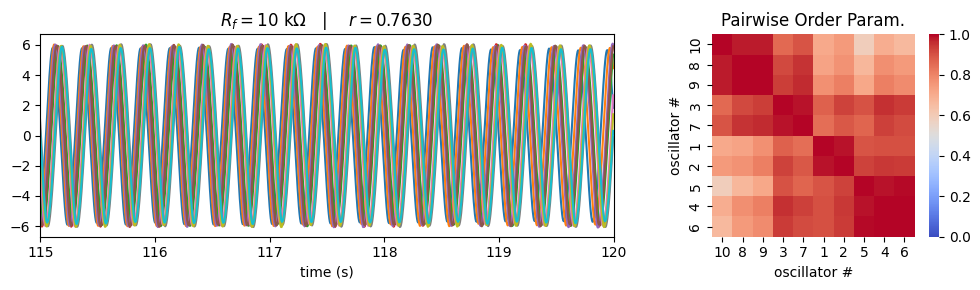

0.87
0.93
1.00
0.93
0.96
1.00
0.87
0.93
1.00
0.90
0.96
1.00
0.90
0.94
1.00
0.90
0.95
1.00
0.85
0.90
0.99
0.67
0.77
0.91
0.71
0.81
0.94
0.59
0.72
0.86


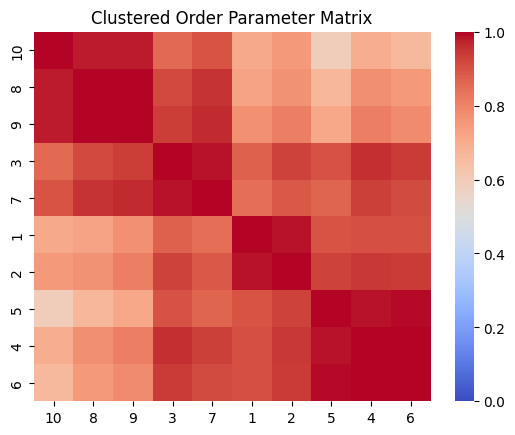

In [ ]:
# oneFile = ['exp002\\Rf_00001000.mat']
oneFile = ['exp002\\Rf_00010000.mat']
# oneFile = ['exp002\\Rf_00050000.mat']

x, t, params, Rf, pc, pcMean, pcStd = analyze_files(oneFile, n=3, numOscillators=10, annot=False);
orderParamMatrix = qnet.plot_clustered_order_parameter_matrix(x, n=3, numOscillators=10, annot=False)
orderParamMatrix

for numOscilator in range(10):
  print("%.2f\n%.2f\n%.2f"%(np.min(orderParamMatrix[numOscilator,:5]), np.average(orderParamMatrix[numOscilator,:5]), np.max(orderParamMatrix[numOscilator,:5])))

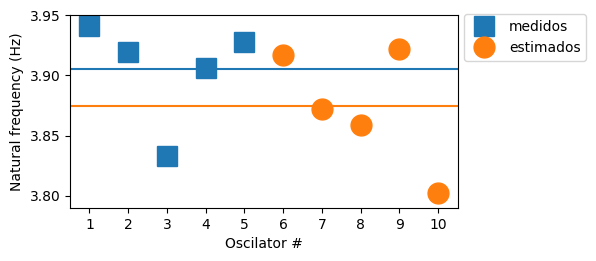

In [71]:
# natural frequencies
natfreqs = np.array([3.9413, 3.9198, 3.8334, 3.9061, 3.9279, 3.9173, 3.8717, 3.8585, 3.9218, 3.8019])
plt.figure(figsize=(5, 2.5))
plt.plot(np.arange(1,6), natfreqs[:5], 's', ms=15, label='medidos')
plt.plot(np.arange(6,11), natfreqs[5:], 'o', ms=15, label='estimados')
plt.axhline(np.mean(natfreqs[:5]), c='C00')
plt.axhline(np.mean(natfreqs[5:]), c='C01')
plt.ylabel('Natural frequency (Hz)')
plt.xlabel('Oscilator #')
plt.ylim([3.79, 3.95])
plt.xlim([.5, 10.5])
plt.legend(bbox_to_anchor=(1.0, 1.04))
plt.xticks(np.arange(1, 11));


